# Simulación de mapa de modos B del CMB (Full-sky con HEALPix)

Generación de mapas de modos B en todo el cielo usando HEALPix (`hp.synfast`), separando la contribución de lente gravitacional y la primordial ($r$).

In [10]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import camb
from camb import model, initialpower

In [11]:
# Parámetros cosmológicos fijos
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06,
                       omk=0, tau=0.06, As=2e-9, ns=0.965,
                       halofit_version='mead', lmax=200)
pars.set_for_lmax(200, lens_potential_accuracy=2)
pars.WantTensors = True

In [12]:
# ---- Componente de lente (r=0) ----
pars_temp = pars.copy()
results = camb.get_results(pars_temp)
inflation_params = initialpower.InitialPowerLaw()
inflation_params.set_params(ns=0.965, r=0.0)
results.power_spectra_from_transfer(inflation_params)

cl_lensed = results.get_total_cls(200, CMB_unit='muK')
cl_unlensed = results.get_unlensed_scalar_cls(200, CMB_unit='muK')
bb_lensing = cl_lensed[:, 2] - cl_unlensed[:, 2]

# ---- Componente tensorial (r=0.1 como referencia) ----
r_ref = 0.1
pars_temp2 = pars.copy()
results2 = camb.get_results(pars_temp2)
inflation_params2 = initialpower.InitialPowerLaw()
inflation_params2.set_params(ns=0.965, r=r_ref)
results2.power_spectra_from_transfer(inflation_params2)
cl_tensor = results2.get_tensor_cls(200, CMB_unit='muK')
bb_tensor_ref = cl_tensor[:, 2]

ell = np.arange(201)

In [13]:
def get_bb_spectrum(Alens, r):
    """Combina lensing + tensor con escalado de A_lens y r."""
    bb = Alens * bb_lensing + (r / r_ref) * bb_tensor_ref
    bb[0] = 0.0
    if len(bb) > 1:
        bb[1] = 0.0
    bb = np.maximum(bb, 0)
    return bb

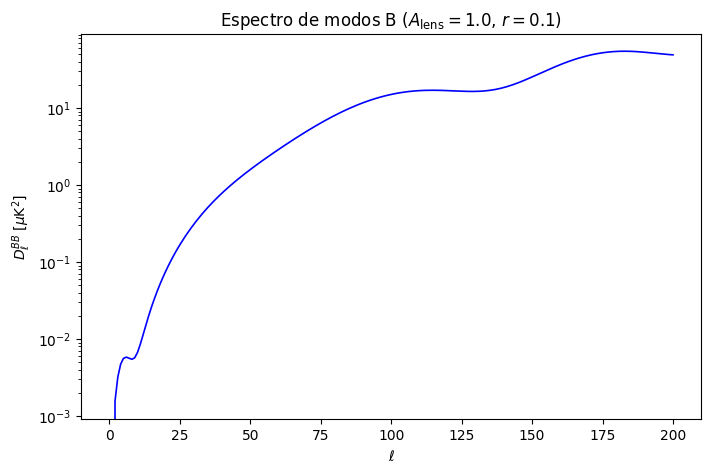

In [14]:
# Parámetros fijos
Alens = 1.0
r = 0.1

bb = get_bb_spectrum(Alens, r)

# D_ell
dBB = bb.copy()
dBB[2:] = bb[2:] * ell[2:] * (ell[2:] + 1) / (2 * np.pi)
dBB[:2] = 0

plt.figure(figsize=(8, 5))
plt.plot(ell, dBB, 'b-', lw=1.2)
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{BB}$ [$\mu$K$^2$]')
plt.title(r'Espectro de modos B ($A_{\mathrm{lens}}=' + f'{Alens}$, $r={r}$)')
plt.show()

Mapa B-mode: mean=-0.0000, rms=3.5420


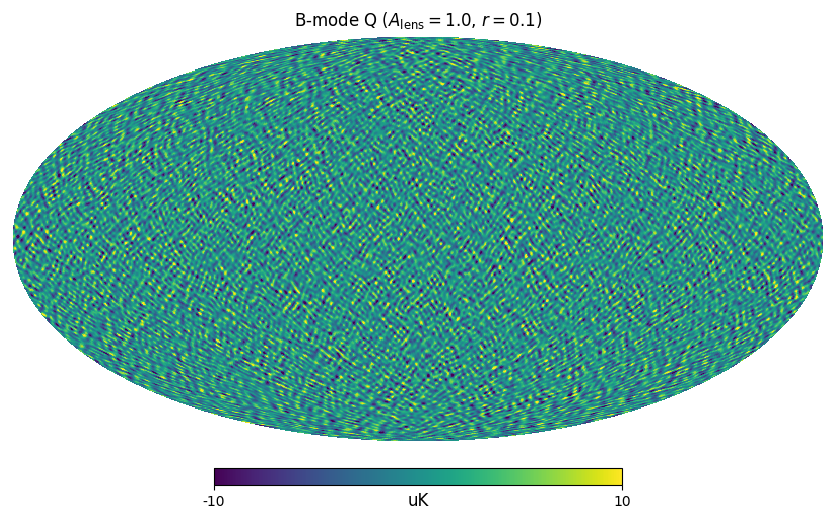

In [15]:
# Resolución HEALPix
nside = 256
np.random.seed(42)

# Generar mapa full-sky con synfast
# synfast(cl, nside, ...) -> [map_T, map_Q, map_U]
# cl debe ser [TT, EE, BB, TE] o un arreglo 1D para un solo espectro
# Para modos B puros: armamos cl como [0, 0, BB, 0]
cl_in = np.zeros((4, 201))
cl_in[2] = bb  # BB

b_map = hp.synfast(cl_in, nside, lmax=200, new=True)
# b_map[0] = I, b_map[1] = Q, b_map[2] = U

print(f"Mapa B-mode: mean={np.mean(b_map[1]):.4f}, rms={np.std(b_map[1]):.4f}")

hp.mollview(b_map[1], title=f'B-mode Q ($A_{{\\mathrm{{lens}}}}={Alens}$, $r={r}$)',
            unit='uK', min=-10, max=10)
plt.show()

## Subplot variando $r$ ($A_{\mathrm{lens}}$ fijo)

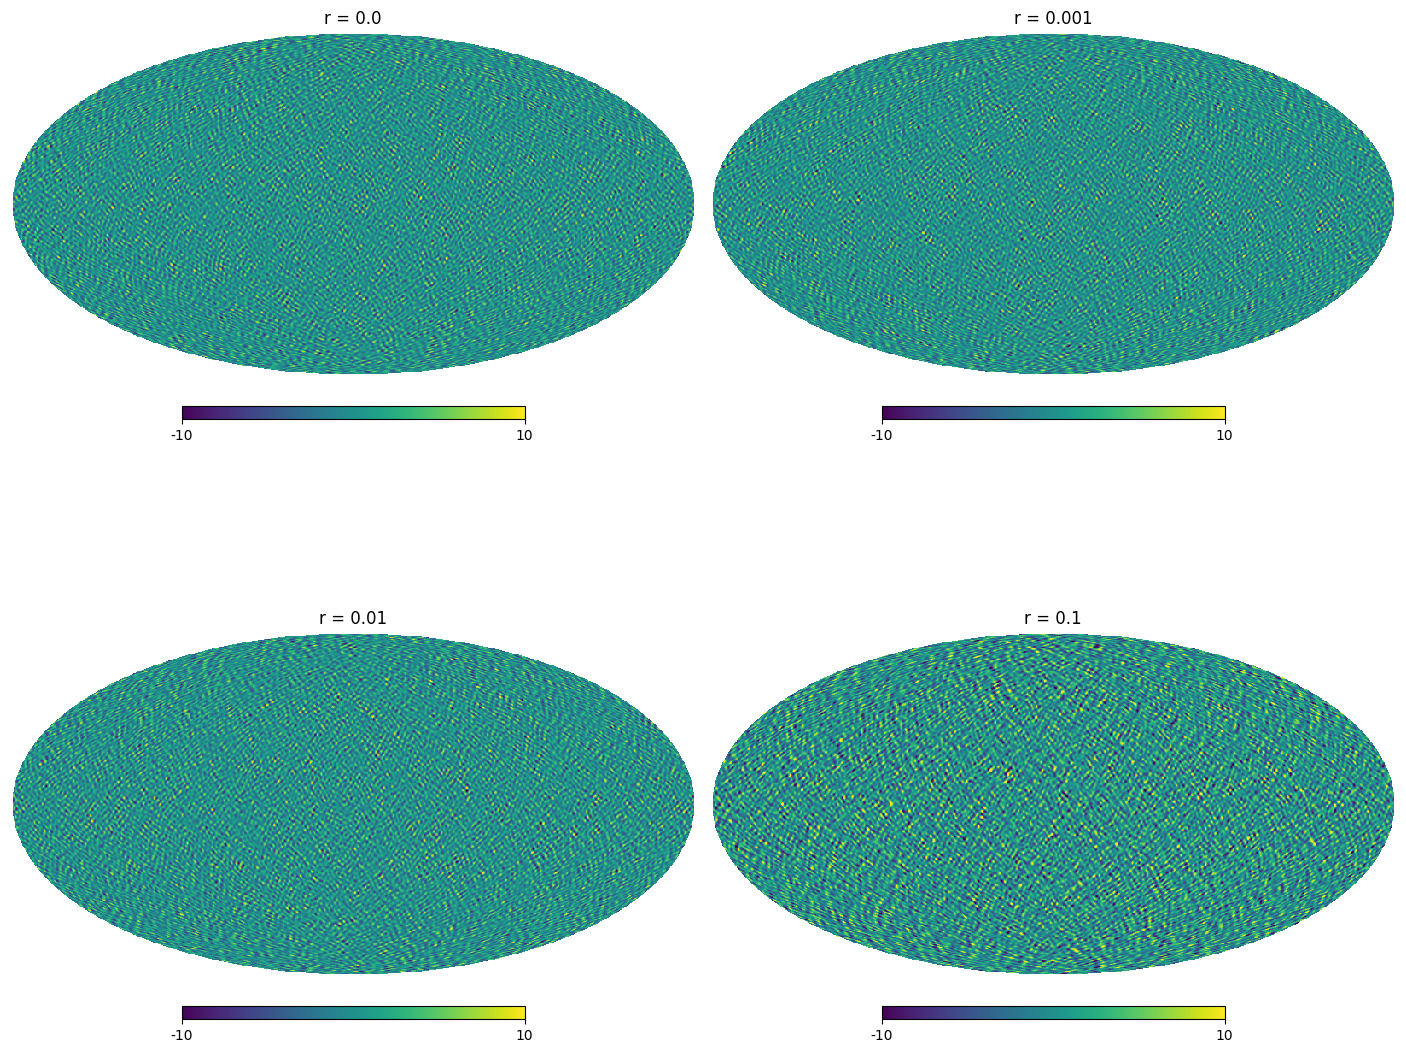

In [16]:
r_vals = [0.0, 0.001, 0.01, 0.1]
Alens_fixed = 1.0

plt.figure(figsize=(14, 12))
for i, r_val in enumerate(r_vals, 1):
    bb = get_bb_spectrum(Alens_fixed, r_val)
    cl_in = np.zeros((4, 201))
    cl_in[2] = bb
    b_map = hp.synfast(cl_in, nside, lmax=200, new=True)
    hp.mollview(b_map[1], title=f'r = {r_val}',
                min=-10, max=10, unit='', sub=(2, 2, i))
plt.show()

## Subplot variando $A_{\mathrm{lens}}$ ($r$ fijo)

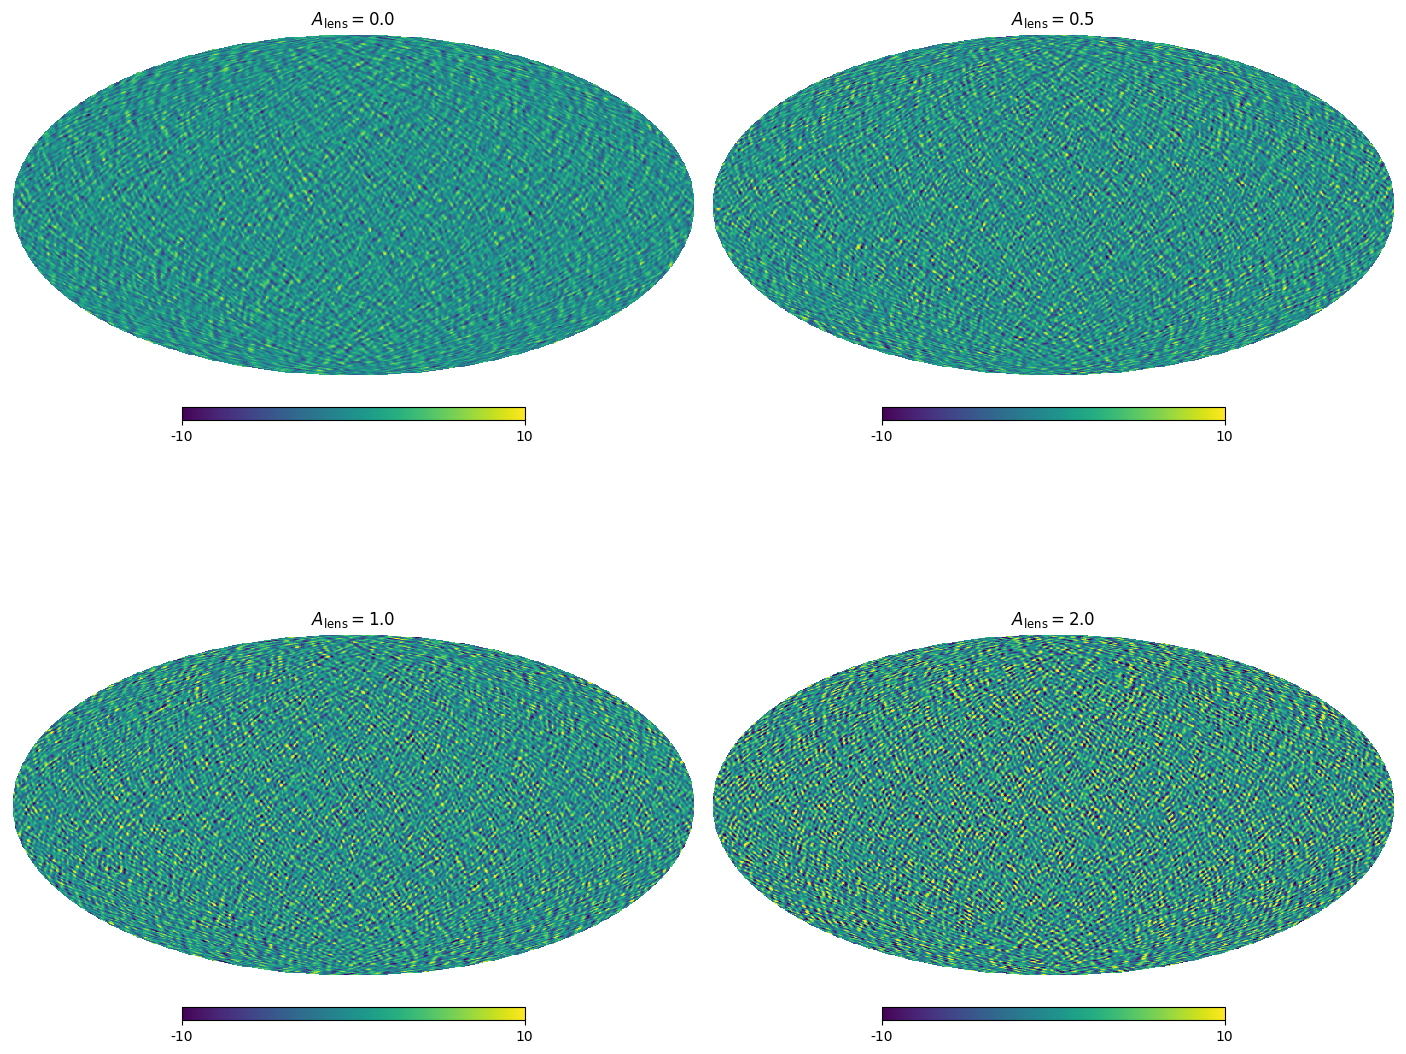

In [17]:
Alens_vals = [0.0, 0.5, 1.0, 2.0]
r_fixed = 0.1

plt.figure(figsize=(14, 12))
for i, Al_val in enumerate(Alens_vals, 1):
    bb = get_bb_spectrum(Al_val, r_fixed)
    cl_in = np.zeros((4, 201))
    cl_in[2] = bb
    b_map = hp.synfast(cl_in, nside, lmax=200, new=True)
    hp.mollview(b_map[1], title=f'$A_{{\\mathrm{{lens}}}} = {Al_val}$',
                min=-10, max=10, unit='', sub=(2, 2, i))
plt.show()

## Parche del mismo tamaño que el mapa flat-sky

El mapa flat-sky del notebook original cubre $\sim 17^\circ \times 17^\circ$ ($N=1024$, $\mathrm{pix\_size}=1'$). Extraemos un parche equivalente del mapa full-sky con `hp.gnomview`.

<Figure size 1000x1000 with 0 Axes>

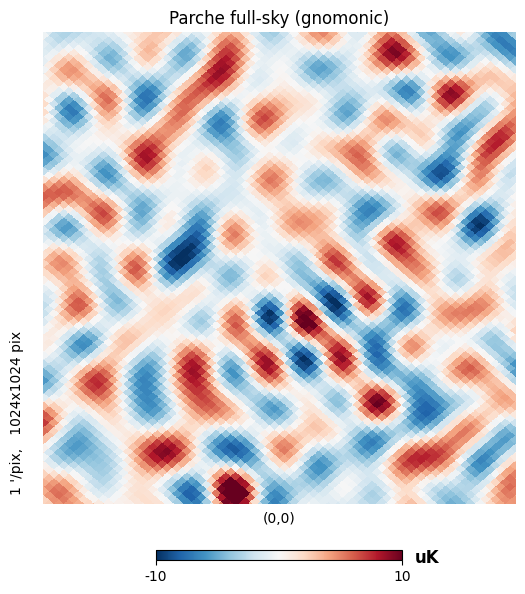

In [18]:
# Mapa full-sky de referencia
bb = get_bb_spectrum(Alens, r)
cl_in = np.zeros((4, 201))
cl_in[2] = bb
b_map_full = hp.synfast(cl_in, nside, lmax=200, new=True)

# Parámetros del flat-sky
N_flat = 2**10
pix_size_flat = 1.0  # arcmin
Xw_flat = N_flat * pix_size_flat / 60.0  # ~17.07 grados

plt.figure(figsize=(10, 10))
hp.gnomview(b_map_full[1], rot=[0, 0], reso=pix_size_flat,
            xsize=N_flat, ysize=N_flat, title='Parche full-sky (gnomonic)',
            cmap='RdBu_r', min=-10, max=10, unit='uK', hold=False)
plt.show()

# Parche de 224x224 pixeles
Npatch = 224
plt.figure(figsize=(6, 6))
hp.gnomview(b_map_full[1], rot=[0, 0], reso=pix_size_flat,
            xsize=Npatch, ysize=Npatch, title=f'Parche {Npatch}x{Npatch} full-sky',
            cmap='RdBu_r', min=-10, max=10, unit='uK', hold=False)
plt.show()